In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV

import xgboost as xgb
import lightgbm as lgb
import shap
import joblib

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("All imports successful.")

All imports successful.


In [3]:
df_raw = pd.read_csv("MPEA_dataset.csv")
print(f"Raw dataset shape: {df_raw.shape}")
print(f"\nColumns:\n{df_raw.columns.tolist()}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")

Raw dataset shape: (1545, 23)

Columns:
['IDENTIFIER: Reference ID', 'FORMULA', 'PROPERTY: Microstructure', 'PROPERTY: Processing method', 'PROPERTY: BCC/FCC/other', 'PROPERTY: grain size ($\\mu$m)', 'PROPERTY: Exp. Density (g/cm$^3$)', 'PROPERTY: Calculated Density (g/cm$^3$)', 'PROPERTY: HV', 'PROPERTY: Type of test', 'PROPERTY: Test temperature ($^\\circ$C)', 'PROPERTY: YS (MPa)', 'PROPERTY: UTS (MPa)', 'PROPERTY: Elongation (%)', 'PROPERTY: Elongation plastic (%)', 'PROPERTY: Exp. Young modulus (GPa)', 'PROPERTY: Calculated Young modulus (GPa)', 'PROPERTY: O content (wppm)', 'PROPERTY: N content (wppm)', 'PROPERTY: C content (wppm)', 'REFERENCE: doi', 'REFERENCE: year', 'REFERENCE: title']

Missing values:
IDENTIFIER: Reference ID                       0
FORMULA                                        0
PROPERTY: Microstructure                     143
PROPERTY: Processing method                  119
PROPERTY: BCC/FCC/other                        0
PROPERTY: grain size ($\mu$m)      

In [4]:
df = df_raw.dropna(subset=['PROPERTY: YS (MPa)']).copy()
df = df.reset_index(drop=True)
print(f"After dropping rows with missing YS: {df.shape}")

After dropping rows with missing YS: (1067, 23)


In [5]:
ELEM_PROPS = {
    'Al': [3,  143, 1.61,  933],  'Co': [9,  125, 1.88, 1768],
    'Cr': [6,  128, 1.66, 2180],  'Cu': [11, 128, 1.90, 1358],
    'Fe': [8,  126, 1.83, 1811],  'Hf': [4,  159, 1.30, 2506],
    'Mn': [7,  127, 1.55, 1519],  'Mo': [6,  139, 2.16, 2896],
    'Nb': [5,  146, 1.60, 2750],  'Ni': [10, 124, 1.91, 1728],
    'Re': [7,  137, 1.90, 3459],  'Si': [4,  111, 1.90, 1687],
    'Ta': [5,  146, 1.50, 3290],  'Ti': [4,  147, 1.54, 1941],
    'V':  [5,  134, 1.63, 2183],  'W':  [6,  139, 2.36, 3695],
    'Zr': [4,  160, 1.33, 2128],  'B':  [3,   87, 2.04, 2349],
    'C':  [4,   77, 2.55, 3823],  'Ca': [2,  197, 1.00, 1115],
    'Ga': [3,  122, 1.81,  303],  'Li': [1,  152, 0.98,  454],
    'Mg': [2,  160, 1.31,  923],  'Nd': [3,  181, 1.14, 1297],
    'Pd': [10, 137, 2.20, 1828],  'Sc': [3,  162, 1.36, 1814],
    'Sn': [4,  140, 1.96,  505],  'Ag': [11, 144, 1.93, 1235],
    'Y':  [3,  180, 1.22, 1799],  'Zn': [12, 134, 1.65,  693],
}
ALL_ELEMENTS = sorted(ELEM_PROPS.keys())

#Binary mixing enthalpy
MIX_H = {
    ('Al','Co'):-19, ('Al','Cr'):-10, ('Al','Cu'):-1,  ('Al','Fe'):-11,
    ('Al','Hf'):-39, ('Al','Mn'):-19, ('Al','Mo'):-2,  ('Al','Nb'):-18,
    ('Al','Ni'):-22, ('Al','Si'):-19, ('Al','Ta'):-19, ('Al','Ti'):-30,
    ('Al','V'): -16, ('Al','W'): -2,  ('Al','Zr'):-44,
    ('Co','Cr'): -4, ('Co','Cu'):  6, ('Co','Fe'): -1, ('Co','Mn'): -5,
    ('Co','Mo'): -5, ('Co','Nb'):-25, ('Co','Ni'):  0, ('Co','Ta'):-24,
    ('Co','Ti'):-28, ('Co','V'): -14, ('Co','W'):  -1, ('Co','Zr'):-41,
    ('Cr','Cu'): 12, ('Cr','Fe'): -1, ('Cr','Mn'):  2, ('Cr','Mo'):  0,
    ('Cr','Nb'): -7, ('Cr','Ni'): -7, ('Cr','Ta'): -7, ('Cr','Ti'): -7,
    ('Cr','V'):  -2, ('Cr','W'):   0, ('Cr','Zr'):-12,
    ('Cu','Fe'): 13, ('Cu','Mn'):  4, ('Cu','Mo'): 19, ('Cu','Nb'):  3,
    ('Cu','Ni'):  4, ('Cu','Ti'): -9, ('Cu','V'):   5, ('Cu','Zr'):-23,
    ('Fe','Mn'):  0, ('Fe','Mo'): -2, ('Fe','Nb'):-16, ('Fe','Ni'): -2,
    ('Fe','Ta'):-15, ('Fe','Ti'):-17, ('Fe','V'):  -7, ('Fe','W'):   0,
    ('Fe','Zr'):-25,
    ('Mn','Mo'): -5, ('Mn','Nb'):-12, ('Mn','Ni'): -8, ('Mn','Ti'):-20,
    ('Mn','V'):  -1, ('Mn','Zr'):-28,
    ('Mo','Nb'): -6, ('Mo','Ni'): -7, ('Mo','Ta'): -5, ('Mo','Ti'): -4,
    ('Mo','V'):  -1, ('Mo','W'):   0, ('Mo','Zr'): -6,
    ('Nb','Ni'):-30, ('Nb','Ta'):  0, ('Nb','Ti'):  2, ('Nb','V'):  -1,
    ('Nb','W'):  -9, ('Nb','Zr'):  4,
    ('Ni','Si'):-13, ('Ni','Ta'):-29, ('Ni','Ti'):-35, ('Ni','V'): -18,
    ('Ni','W'):  -3, ('Ni','Zr'):-49,
    ('Si','Ti'):-28, ('Ta','Ti'): -9, ('Ta','V'):  -1, ('Ta','W'):  -7,
    ('Ta','Zr'): -2, ('Ti','V'):  -2, ('Ti','W'):  -7, ('Ti','Zr'):  0,
    ('V','W'):   -1, ('V','Zr'):  -4, ('W','Zr'):  -9,
}


def parse_formula(formula):
    """Parse MPEA formula string into normalised mole fractions.
    Example: 'Al0.25 Co1 Fe1 Ni1' → {'Al': 0.077, 'Co': 0.308, ...}
    """
    matches = re.findall(r'([A-Z][a-z]?)([\d.]+)', str(formula))
    comp = {el: float(amt) for el, amt in matches}
    total = sum(comp.values())
    return {el: amt / total for el, amt in comp.items()}


def compute_thermo_features(formula):
    """Compute all thermodynamic and physical descriptors for one formula."""
    comp     = parse_formula(formula)
    elements = list(comp.keys())
    fracs    = list(comp.values())
    n        = len(elements)


    vec_vals = [ELEM_PROPS.get(el, [0, 0,   0,    0])[0] for el in elements]
    r_vals   = [ELEM_PROPS.get(el, [0, 130, 0,    0])[1] for el in elements]
    en_vals  = [ELEM_PROPS.get(el, [0, 0,   1.8,  0])[2] for el in elements]
    mp_vals  = [ELEM_PROPS.get(el, [0, 0,   0, 1500])[3] for el in elements]

    # Valence electron concentration
    VEC = sum(f * v for f, v in zip(fracs, vec_vals))

    # Atomic size mismatch (delta, %)
    r_bar    = sum(f * r for f, r in zip(fracs, r_vals))
    delta_r  = np.sqrt(sum(f * (1 - r / r_bar) ** 2 for f, r in zip(fracs, r_vals))) * 100

    # Electronegativity difference
    en_bar   = sum(f * e for f, e in zip(fracs, en_vals))
    delta_en = np.sqrt(sum(f * (e - en_bar) ** 2 for f, e in zip(fracs, en_vals)))

    # Ideal mixing entropy (J/mol·K)
    S_mix = -8.314 * sum(f * np.log(f) for f in fracs if f > 0)

    # Mixing enthalpy (kJ/mol)
    H_mix = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            key = (min(elements[i], elements[j]), max(elements[i], elements[j]))
            H_mix += 4 * fracs[i] * fracs[j] * MIX_H.get(key, 0)

    # Weighted average melting point (K)
    T_melt = sum(f * m for f, m in zip(fracs, mp_vals))

    # Omega parameter
    omega = T_melt * S_mix / (abs(H_mix) * 1000 + 1e-9)

    # Elemental mole fractions (30 elements, zero if absent)
    x_features = {f'x_{el}': comp.get(el, 0.0) for el in ALL_ELEMENTS}

    return {
        'num_elements': n,
        'VEC':          VEC,
        'delta_r':      delta_r,
        'delta_en':     delta_en,
        'S_mix':        S_mix,
        'H_mix':        H_mix,
        'T_melt':       T_melt,
        'omega':        omega,
        **x_features,
    }


print("Computing thermodynamic features...")
feat_df = pd.DataFrame([compute_thermo_features(f) for f in df['FORMULA']])
print(f"Feature matrix shape after thermo features: {feat_df.shape}")

Computing thermodynamic features...
Feature matrix shape after thermo features: (1067, 38)


In [6]:
temp_col = [c for c in df.columns if 'temperature' in c.lower()][0]
feat_df['test_temperature'] = df[temp_col].values

# --- Test type: Compression (C) vs Tension (T) ---
feat_df['test_type_compression'] = (df['PROPERTY: Type of test'] == 'C').astype(int).values

# --- Microstructure — simplified to 5 meaningful groups ---
# Original has 38 unique values; many appear < 5 times (noise, not signal).
# Groups: BCC_single, FCC_single, BCC_based (BCC + secondary phases),
#         FCC_based (FCC + secondary phases), Mixed (BCC+FCC coexistence)
def simplify_microstructure(m):
    if pd.isna(m):            return 'Unknown'
    m = str(m)
    if m == 'BCC':            return 'BCC_single'
    if m == 'FCC':            return 'FCC_single'
    if 'FCC' in m and 'BCC' not in m and 'B2' not in m:
                              return 'FCC_based'
    if 'BCC' in m and 'FCC' not in m:
                              return 'BCC_based'
    return 'Mixed'

micro_series = df['PROPERTY: Microstructure'].apply(simplify_microstructure)
micro_dummies = pd.get_dummies(micro_series, prefix='micro').astype(int)
feat_df = pd.concat([feat_df, micro_dummies], axis=1)
print(f"Microstructure groups:\n{micro_series.value_counts()}")

# --- Processing method — keep CAST, WROUGHT, POWDER, ANNEAL; rest → OTHER ---
def simplify_processing(p):
    if pd.isna(p): return 'CAST'   # most common; safe default
    return p if p in ['CAST', 'WROUGHT', 'POWDER', 'ANNEAL'] else 'OTHER'

proc_series = df['PROPERTY: Processing method'].apply(simplify_processing)
proc_dummies = pd.get_dummies(proc_series, prefix='proc').astype(int)
feat_df = pd.concat([feat_df, proc_dummies], axis=1)
print(f"\nProcessing method counts:\n{proc_series.value_counts()}")

# --- Grain size — 860/1067 rows are missing ---
# Strategy: binary flag (was it measured?) + log-transformed value (0 if unknown)
# This is honest: we tell the model "we don't know" rather than imputing a fake median.
gs_col = [c for c in df.columns if 'grain' in c.lower()][0]
feat_df['grain_size_known'] = (~df[gs_col].isna()).astype(int).values
feat_df['grain_size_log']   = np.log1p(df[gs_col].fillna(0)).values

# --- Target ---
feat_df['YS_MPa'] = df['PROPERTY: YS (MPa)'].values

print(f"\nFinal dataset shape: {feat_df.shape}")
print(f"Total null values  : {feat_df.isnull().sum().sum()}")   # should be 0
feat_df.head()

Microstructure groups:
PROPERTY: Microstructure
BCC_single    372
BCC_based     225
FCC_single    186
Mixed         141
FCC_based      92
Unknown        51
Name: count, dtype: int64

Processing method counts:
PROPERTY: Processing method
CAST       491
WROUGHT    235
ANNEAL     185
OTHER      107
POWDER      49
Name: count, dtype: int64

Final dataset shape: (1067, 54)
Total null values  : 0


,num_elements,VEC,delta_r,delta_en,S_mix,H_mix,T_melt,omega,x_Ag,x_Al,...,micro_Mixed,micro_Unknown,proc_ANNEAL,proc_CAST,proc_OTHER,proc_POWDER,proc_WROUGHT,grain_size_known,grain_size_log,YS_MPa
0,4,8.538462,3.845543,0.077000,10.685926,-6.059172,1704.692308,3.006387,0.0,0.076923,...,0,0,0,1,0,0,0,0,0.0,158.0
1,4,8.142857,4.972811,0.097080,11.238732,-9.469388,1649.571429,1.957792,0.0,0.142857,...,1,0,0,1,0,0,0,0,0.0,346.0
2,4,7.800000,5.627482,0.109390,11.467436,-11.946667,1601.800000,1.537545,0.0,0.200000,...,1,0,0,1,0,0,0,0,0.0,794.0
3,4,7.500000,6.043427,0.117553,11.525651,-13.750000,1560.000000,1.307638,0.0,0.250000,...,0,0,0,1,0,0,0,0,0.0,964.0
4,3,9.000000,0.653197,0.032998,9.133863,-1.333333,1769.000000,12.118352,0.0,0.000000,...,0,0,0,1,0,0,0,0,0.0,204.0


In [8]:
feat_df.to_csv("YS_MPEA_ML_ready_v2.csv", index=False)
print("Saved: YS_MPEA_ML_ready_v2.csv")
print(f"Shape: {feat_df.shape}")
print(f"\nFeature columns ({feat_df.shape[1]-1}):")
print([c for c in feat_df.columns if c != 'YS_MPa'])

Saved: YS_MPEA_ML_ready_v2.csv
Shape: (1067, 54)

Feature columns (53):
['num_elements', 'VEC', 'delta_r', 'delta_en', 'S_mix', 'H_mix', 'T_melt', 'omega', 'x_Ag', 'x_Al', 'x_B', 'x_C', 'x_Ca', 'x_Co', 'x_Cr', 'x_Cu', 'x_Fe', 'x_Ga', 'x_Hf', 'x_Li', 'x_Mg', 'x_Mn', 'x_Mo', 'x_Nb', 'x_Nd', 'x_Ni', 'x_Pd', 'x_Re', 'x_Sc', 'x_Si', 'x_Sn', 'x_Ta', 'x_Ti', 'x_V', 'x_W', 'x_Y', 'x_Zn', 'x_Zr', 'test_temperature', 'test_type_compression', 'micro_BCC_based', 'micro_BCC_single', 'micro_FCC_based', 'micro_FCC_single', 'micro_Mixed', 'micro_Unknown', 'proc_ANNEAL', 'proc_CAST', 'proc_OTHER', 'proc_POWDER', 'proc_WROUGHT', 'grain_size_known', 'grain_size_log']


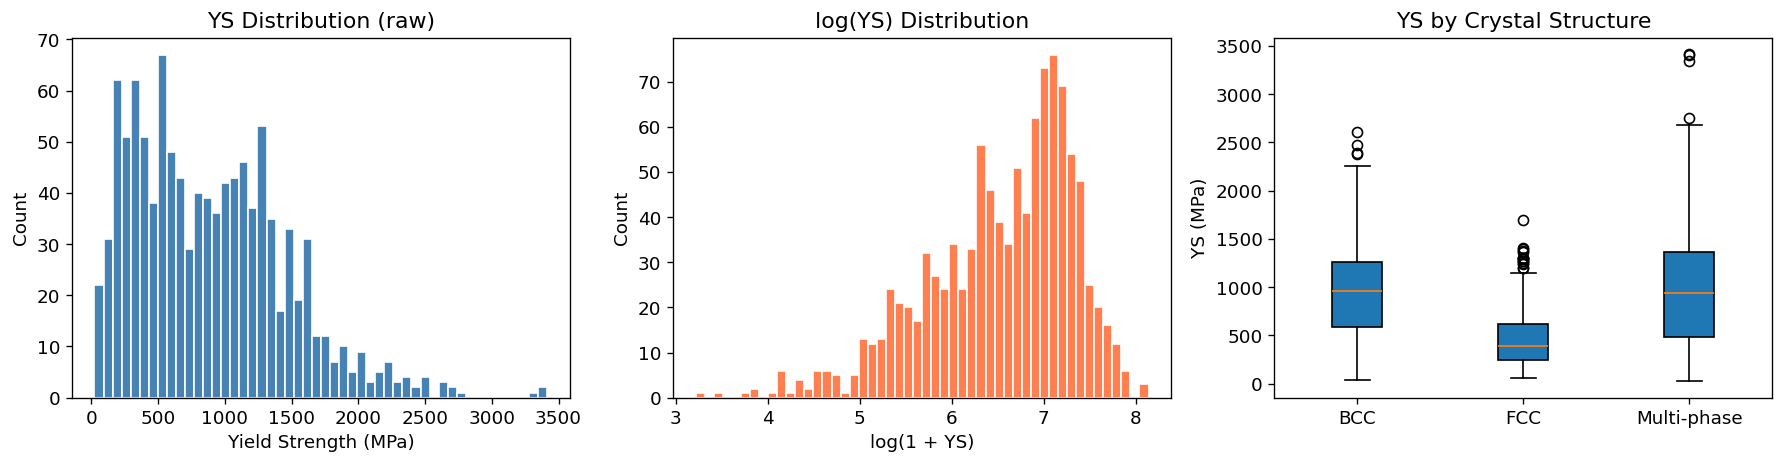

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw YS distribution
axes[0].hist(feat_df['YS_MPa'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('YS Distribution (raw)')
axes[0].set_xlabel('Yield Strength (MPa)')
axes[0].set_ylabel('Count')

# Log-transformed YS
axes[1].hist(np.log1p(feat_df['YS_MPa']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('log(YS) Distribution')
axes[1].set_xlabel('log(1 + YS)')
axes[1].set_ylabel('Count')

# YS by crystal structure
bcc_mask = feat_df['micro_BCC_single'] == 1
fcc_mask = feat_df['micro_FCC_single'] == 1
axes[2].boxplot(
    [feat_df[bcc_mask]['YS_MPa'], feat_df[fcc_mask]['YS_MPa'],
     feat_df[~bcc_mask & ~fcc_mask]['YS_MPa']],
    labels=['BCC', 'FCC', 'Multi-phase'],
    patch_artist=True
)
axes[2].set_title('YS by Crystal Structure')
axes[2].set_ylabel('YS (MPa)')

plt.tight_layout()
plt.savefig("eda_target_distribution.png", bbox_inches='tight')
plt.show()

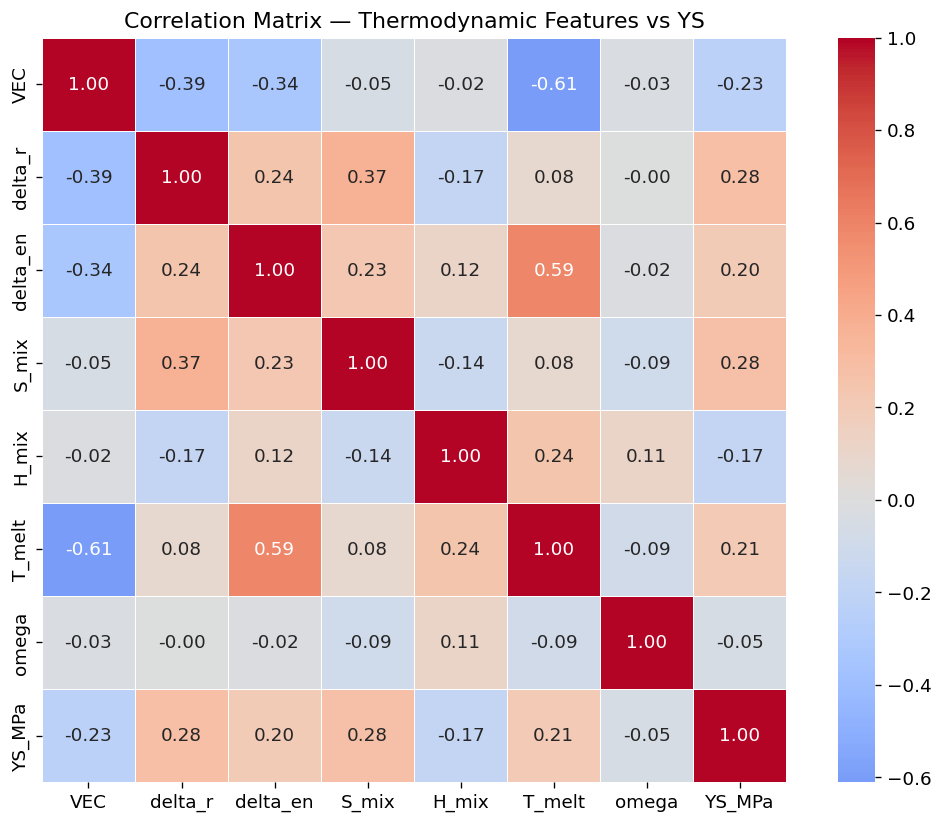

In [10]:
thermo_cols = ['VEC', 'delta_r', 'delta_en', 'S_mix', 'H_mix', 'T_melt', 'omega', 'YS_MPa']
corr = feat_df[thermo_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Thermodynamic Features vs YS')
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", bbox_inches='tight')
plt.show()

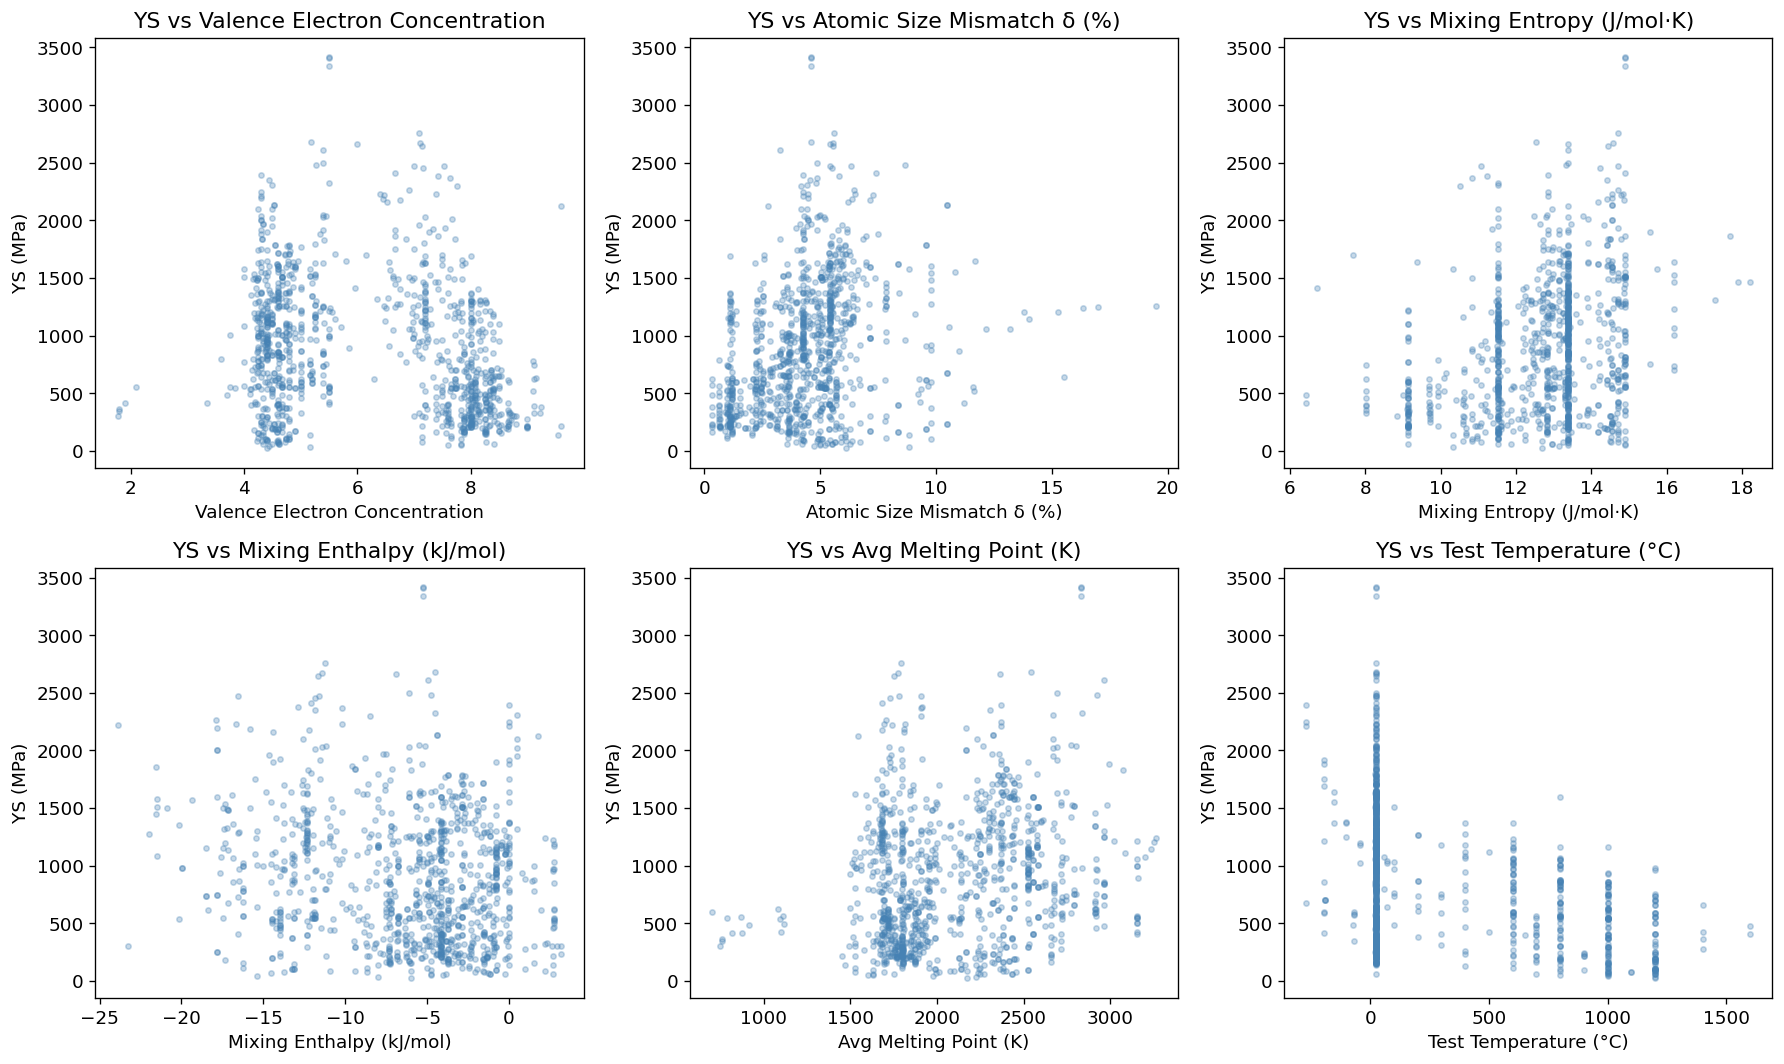

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
feature_pairs = [
    ('VEC',              'Valence Electron Concentration'),
    ('delta_r',          'Atomic Size Mismatch δ (%)'),
    ('S_mix',            'Mixing Entropy (J/mol·K)'),
    ('H_mix',            'Mixing Enthalpy (kJ/mol)'),
    ('T_melt',           'Avg Melting Point (K)'),
    ('test_temperature', 'Test Temperature (°C)'),
]

for ax, (feat, label) in zip(axes.flat, feature_pairs):
    ax.scatter(feat_df[feat], feat_df['YS_MPa'],
               alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('YS (MPa)')
    ax.set_title(f'YS vs {label}')

plt.tight_layout()
plt.savefig("eda_scatter_plots.png", bbox_inches='tight')
plt.show()

In [12]:
X = feat_df.drop(columns=['YS_MPa'])
y = feat_df['YS_MPa']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train YS mean: {y_train.mean():.1f} MPa  |  Test YS mean: {y_test.mean():.1f} MPa")

Train: (853, 53)  |  Test: (214, 53)
Train YS mean: 882.4 MPa  |  Test YS mean: 920.2 MPa


In [13]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_features='sqrt',
        min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    ),
}

print("Running 5-fold cross-validation on training set...\n")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s}  CV R² = {scores.mean():.4f} ± {scores.std():.4f}")

Running 5-fold cross-validation on training set...

Ridge Regression           CV R² = 0.6650 ± 0.0424
Random Forest              CV R² = 0.7303 ± 0.0182
Gradient Boosting          CV R² = 0.7940 ± 0.0202
XGBoost                    CV R² = 0.8021 ± 0.0248


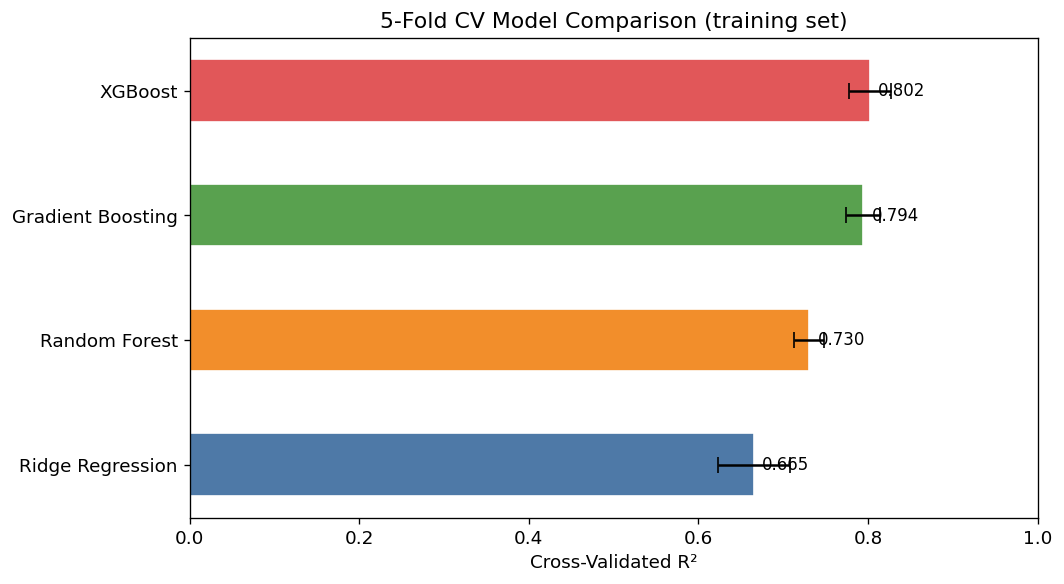

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor='white',
               height=0.5, capsize=5)
ax.set_xlabel('Cross-Validated R²')
ax.set_title('5-Fold CV Model Comparison (training set)')
ax.set_xlim(0, 1)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.01, bar.get_y() + bar.get_height()/2,
            f'{mean:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches='tight')
plt.show()

In [23]:
param_dist = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4],              # ← changed, was [3,4,5,6]
    'learning_rate':    [0.01, 0.03, 0.05],
    'subsample':        [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [3, 5, 10],          # ← changed, was [1,3,5]
    'gamma':            [0.1, 0.3, 0.5],     # ← changed, was [0,0.1,0.3]
    'reg_alpha':        [0.5, 1.0, 2.0],     # ← changed, was [0,0.1,0.5,1.0]
    'reg_lambda':       [2.0, 3.0, 5.0],     # ← changed, was [1,1.5,2.0]
}

xgb_base = xgb.XGBRegressor(
    random_state=42, n_jobs=-1, verbosity=0, objective='reg:squarederror'
)

random_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist,
    n_iter=60,              # 60 random combinations
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Running RandomizedSearchCV (this takes ~3-5 minutes in Colab)...")
random_search.fit(X_train, y_train)

print(f"\nBest CV R²  : {random_search.best_score_:.4f}")
print(f"Best params : {random_search.best_params_}")

best_model = random_search.best_estimator_

Running RandomizedSearchCV (this takes ~3-5 minutes in Colab)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV R²  : 0.8097
Best params : {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 2.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.6}


In [24]:
y_pred_test  = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

r2_test  = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test= np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=" * 45)
print("        FINAL MODEL PERFORMANCE")
print("=" * 45)
print(f"  Train R²  : {r2_train:.4f}")
print(f"  Test  R²  : {r2_test:.4f}   ← primary metric")
print(f"  Test  MAE : {mae_test:.1f} MPa")
print(f"  Test  RMSE: {rmse_test:.1f} MPa")
print(f"  Target mean (test): {y_test.mean():.1f} MPa")
print("=" * 45)

# Overfit check
gap = r2_train - r2_test
if gap < 0.05:
    print("\n✓ Train/test gap < 0.05 — no significant overfitting")
elif gap < 0.10:
    print(f"\n⚠ Mild overfit (gap = {gap:.3f}) — acceptable for tree models")
else:
    print(f"\n✗ Overfit gap = {gap:.3f} — consider more regularisation")



        FINAL MODEL PERFORMANCE
  Train R²  : 0.9514
  Test  R²  : 0.8082   ← primary metric
  Test  MAE : 172.1 MPa
  Test  RMSE: 257.1 MPa
  Target mean (test): 920.2 MPa

✗ Overfit gap = 0.143 — consider more regularisation


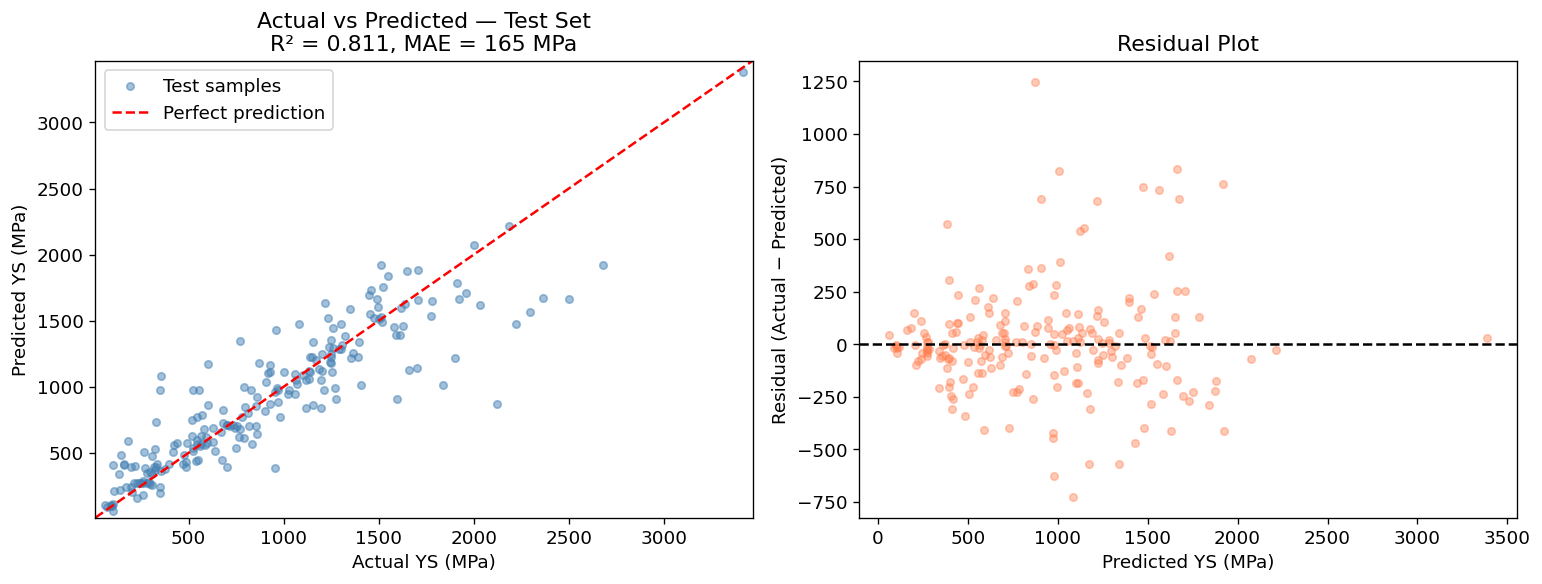

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Parity plot
ax = axes[0]
lims = [min(y_test.min(), y_pred_test.min()) - 50,
        max(y_test.max(), y_pred_test.max()) + 50]
ax.scatter(y_test, y_pred_test, alpha=0.5, s=20, color='steelblue', label='Test samples')
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual YS (MPa)')
ax.set_ylabel('Predicted YS (MPa)')
ax.set_title(f'Actual vs Predicted — Test Set\nR² = {r2_test:.3f}, MAE = {mae_test:.0f} MPa')
ax.legend()
ax.set_xlim(lims); ax.set_ylim(lims)

# Residual plot
ax = axes[1]
residuals = y_test.values - y_pred_test
ax.scatter(y_pred_test, residuals, alpha=0.4, s=20, color='coral')
ax.axhline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('Predicted YS (MPa)')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residual Plot')

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", bbox_inches='tight')
plt.show()

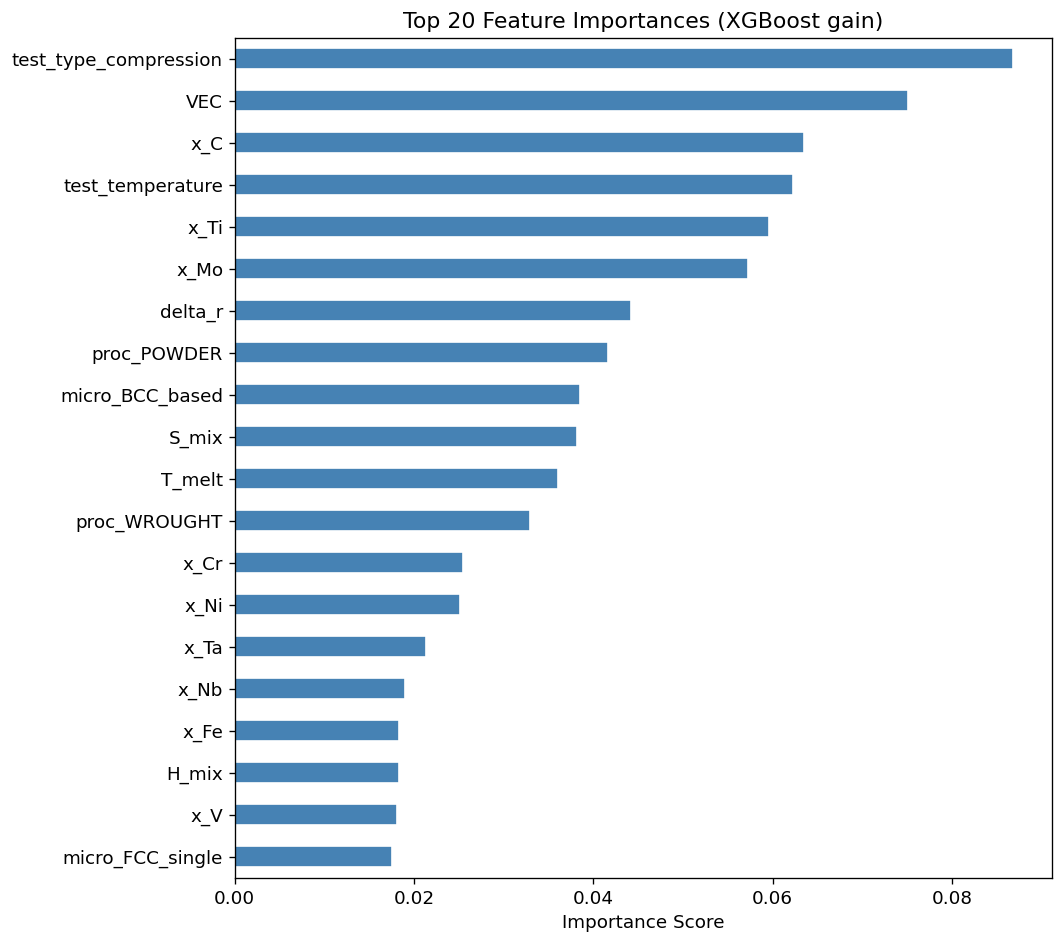


Top 10 features:
test_type_compression    0.086859
VEC                      0.075123
x_C                      0.063438
test_temperature         0.062234
x_Ti                     0.059631
x_Mo                     0.057237
delta_r                  0.044182
proc_POWDER              0.041650
micro_BCC_based          0.038505
S_mix                    0.038142
dtype: float32


In [18]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
top20.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances (XGBoost gain)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig("feature_importances.png", bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
print(importances.nlargest(10))

Computing SHAP values (takes ~1 minute)...


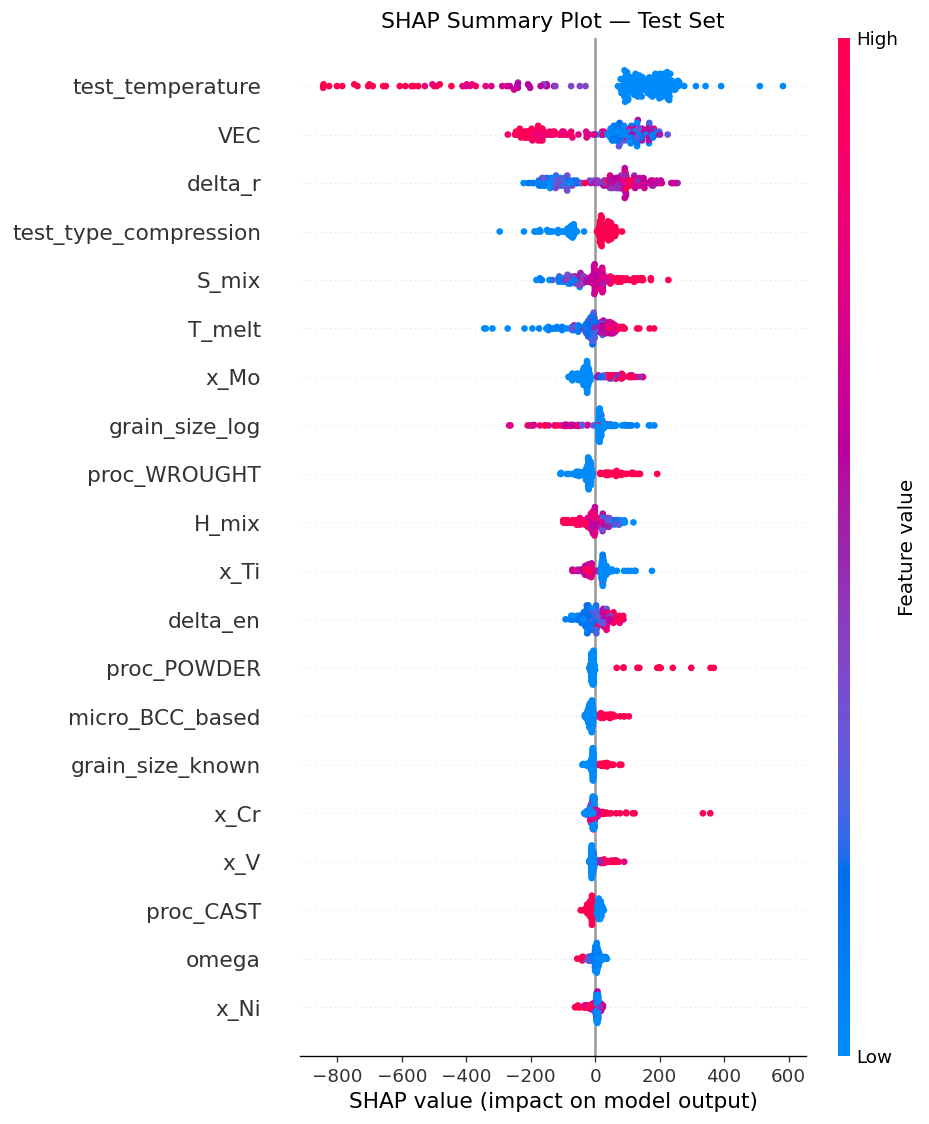

In [19]:
print("Computing SHAP values (takes ~1 minute)...")
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — feature impact on predictions
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='dot',
                  max_display=20, show=False)
plt.title('SHAP Summary Plot — Test Set')
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches='tight')
plt.show()

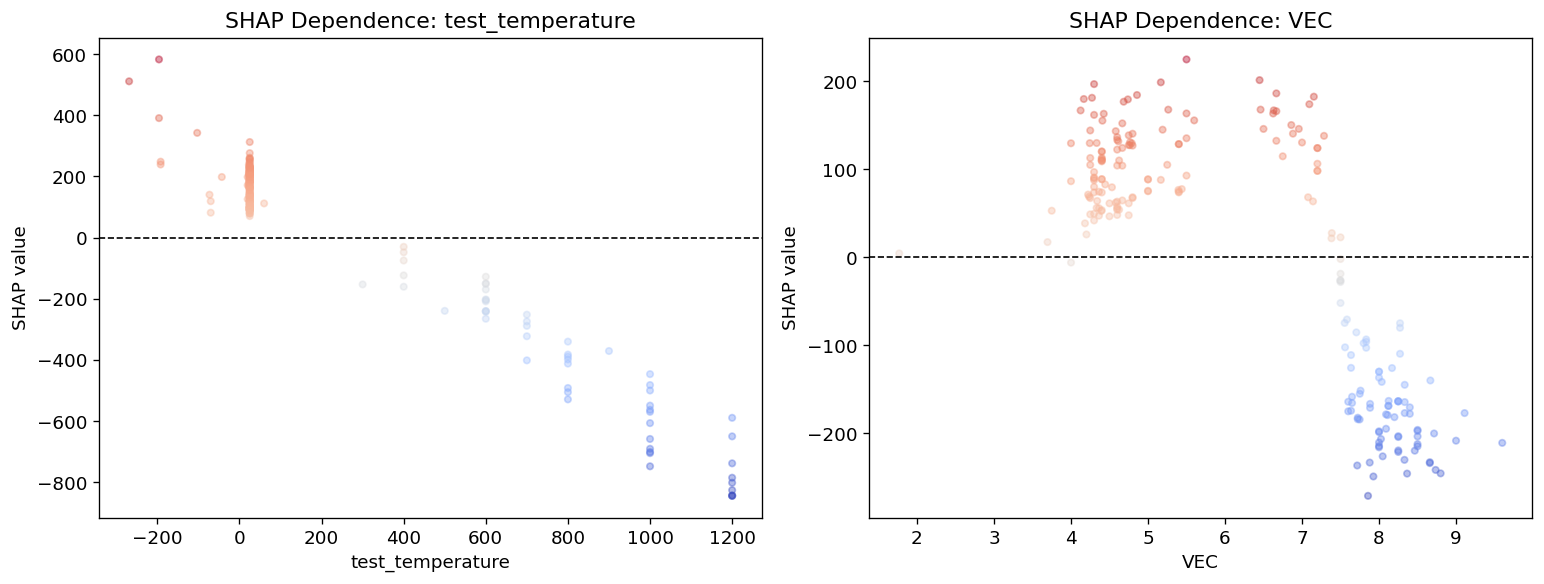

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat in zip(axes, ['test_temperature', 'VEC']):
    feat_idx = list(X_test.columns).index(feat)
    ax.scatter(X_test[feat].values,
               shap_values[:, feat_idx],
               alpha=0.4, s=15, c=shap_values[:, feat_idx],
               cmap='coolwarm')
    ax.axhline(0, color='black', lw=1, linestyle='--')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.savefig("shap_dependence.png", bbox_inches='tight')
plt.show()

In [21]:
joblib.dump(best_model, 'YS_model_v2.pkl')
feat_df.drop(columns=['YS_MPa']).columns.tolist()   # save column order for inference

# Save column list so prediction script knows the expected input order
feature_cols = X.columns.tolist()
pd.Series(feature_cols).to_csv('feature_columns.csv', index=False, header=False)

print("Saved: YS_model_v2.pkl")
print("Saved: feature_columns.csv")
print(f"\nModel trained on {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Final test R² = {r2_test:.4f}")


Saved: YS_model_v2.pkl
Saved: feature_columns.csv

Model trained on 853 samples, 53 features
Final test R² = 0.8114


In [22]:
def predict_yield_strength(formula, test_temp_C, test_type,
                            microstructure, processing_method,
                            grain_size_um=None):
    """
    Predict yield strength for a new MPEA composition.

    Parameters
    ----------
    formula          : str   e.g. 'Al0.25 Co1 Cr1 Fe1 Ni1'
    test_temp_C      : float test temperature in Celsius (25 for room temp)
    test_type        : str   'C' for compression, 'T' for tension
    microstructure   : str   one of 'BCC', 'FCC', 'BCC+Sec.', 'FCC+BCC', etc.
    processing_method: str   'CAST', 'WROUGHT', 'POWDER', 'ANNEAL', or 'OTHER'
    grain_size_um    : float grain size in microns, or None if unknown

    Returns
    -------
    float : predicted yield strength in MPa
    """
    # Load model and feature columns
    model     = joblib.load('YS_model_v2.pkl')
    feat_cols = pd.read_csv('feature_columns.csv', header=None)[0].tolist()

    # Build feature row
    feat = compute_thermo_features(formula)
    feat['test_temperature']      = test_temp_C
    feat['test_type_compression'] = 1 if test_type == 'C' else 0

    # Microstructure dummies
    micro_group = simplify_microstructure(microstructure)
    for g in ['BCC_based', 'BCC_single', 'FCC_based', 'FCC_single', 'Mixed', 'Unknown']:
        feat[f'micro_{g}'] = 1 if micro_group == g else 0

    # Processing dummies
    proc = processing_method if processing_method in ['CAST','WROUGHT','POWDER','ANNEAL'] else 'OTHER'
    for p in ['ANNEAL', 'CAST', 'OTHER', 'POWDER', 'WROUGHT']:
        feat[f'proc_{p}'] = 1 if proc == p else 0

    # Grain size
    feat['grain_size_known'] = 0 if grain_size_um is None else 1
    feat['grain_size_log']   = np.log1p(grain_size_um) if grain_size_um else 0.0

    # Align to training columns
    row = pd.DataFrame([feat])[feat_cols]
    ys_pred = model.predict(row)[0]

    print(f"Formula        : {formula}")
    print(f"Test conditions: {test_temp_C}°C, {'Compression' if test_type=='C' else 'Tension'}")
    print(f"Microstructure : {microstructure} → {micro_group}")
    print(f"Processing     : {processing_method}")
    print(f"Predicted YS   : {ys_pred:.0f} MPa")
    return ys_pred


# --- Example prediction ---
predict_yield_strength(
    formula           = 'Al0.5 Co1 Cr1 Fe1 Ni1',
    test_temp_C       = 25,
    test_type         = 'C',
    microstructure    = 'BCC',
    processing_method = 'CAST',
    grain_size_um     = None
)

Formula        : Al0.5 Co1 Cr1 Fe1 Ni1
Test conditions: 25°C, Compression
Microstructure : BCC → BCC_single
Processing     : CAST
Predicted YS   : 999 MPa


np.float32(999.2729)

In [25]:
import joblib
import pandas as pd

# 1. Save the trained XGBoost model
joblib.dump(best_model, "YS_model_v2.pkl")
# replace 'best_model' with whatever your trained xgb model variable is named

# 2. Save the feature columns (the exact columns X_train had)
pd.DataFrame(X_train.columns, columns=["feature"]).to_csv("feature_columns.csv", index=False)

print("✅ YS_model_v2.pkl saved")
print("✅ feature_columns.csv saved")
print("Feature count:", X_train.shape[1])

✅ YS_model_v2.pkl saved
✅ feature_columns.csv saved
Feature count: 53
